In [1]:
import os, pandas
import omnipath, mygene
import matplotlib.pyplot

In [2]:
input_file = "db/ChEA_2022.txt"

with open(input_file) as f:
    header = f.readline().rstrip("\n").split("\t")
   

    for i, line in enumerate(f):
        if i >= 999999:
            break
        fields = line.rstrip("\n").split("\t")
        if 'MITF' in fields[0]:
            targets = fields[1:]
            
print(len(targets))
targets = [x for x in targets[1:] if x.strip()]
print(len(targets))
known_targets = list(set(targets))
print(len(known_targets), known_targets[:10])

4616
4614
4614 ['OSBP', 'ABHD4', 'LIMCH1', 'RAB2A', 'GMPR', 'CHIC1', 'COL22A1', 'E2F3', 'COX5A', 'IGF2BP3']


In [3]:
def metrics(known, predicted):
    known = set(known)
    predicted = set(predicted)

    tp = len(known & predicted)
    fp = len(predicted - known)
    fn = len(known - predicted)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0

    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    f2 = (5 * precision * recall / (4 * precision + recall)) if (4 * precision + recall) else 0.0

    jaccard = tp / len(known | predicted) if (known | predicted) else 0.0

    print(f2)
    print()

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "F2": f2,
        "jaccard": jaccard,
        "n_known": len(known),
        "n_predicted": len(predicted),
    }

In [4]:
base_dir = "/Users/adrian/research/bmcbf/004_keilir/results/04_necio_f2_score/"

rows = []

for fname in sorted(os.listdir(base_dir)):
    if not fname.endswith(".txt"):
        continue
    if ".genes.multi." not in fname:
        continue  # skip anything else

    # Example: black.a.genes.multi.10kb.txt
    stem = fname[:-4]
    parts = stem.split(".")
    if len(parts) < 5:
        continue

    color = parts[0]
    condition = parts[1]
    window = parts[-1]

    print(color, condition, window)

    path = os.path.join(base_dir, fname)
    df = pandas.read_csv(path, sep="\t", header=None)

    identified = set(df.iloc[:, 0].dropna().astype(str))
    identified = {g for g in identified if g != "" and g.lower() != "nan"}

    res = metrics(known_targets, identified)
    

    rows.append({
        "file": fname,
        "color": color,
        "condition": condition,
        "window": window,
        **res,
    })

results_df = pandas.DataFrame(rows)

# Optional: enforce a logical window order
window_order = ["c150b", "c300b", "c500b", "s500b", "c1kb", "s1kb", "2kb", "5kb", "10kb", "25kb", "50kb"]
results_df["window"] = pandas.Categorical(results_df["window"], categories=window_order, ordered=True)

results_df.sort_values(["color", "condition", "window"])
results_df

black a 10kb
0.32029458764677277

black a 25kb
0.3600657201314403

black a 2kb
0.2718296454913157

black a 50kb
0.388116236996834

black a 5kb
0.29808940827304764

black a c150b
0.21097964155211416

black a c1kb
0.22550808265093983

black a c300b
0.21420225886018435

black a c500b
0.21431346311563865

black a s1kb
0.23893989983305508

black a s500b
0.21894049969949347

black m 10kb
0.2861989317164718

black m 25kb
0.3524724773432273

black m 2kb
0.1796539669896898

black m 50kb
0.39219069360019104

black m 5kb
0.23485213757634202

black m c150b
0.08230761533073153

black m c1kb
0.11259846324844149

black m c300b
0.08916153387641565

black m c500b
0.09339328951919751

black m s1kb
0.12818686796752599

black m s500b
0.09783677482792527

gold a 10kb
0.31987351009486736

gold a 25kb
0.3599230840802655

gold a 2kb
0.2715084685256436

gold a 50kb
0.3877262443438914

gold a 5kb
0.2978510188175036

gold a c150b
0.21099799878186723

gold a c1kb
0.22552722026562563

gold a c300b
0.21422079889211

,file,color,condition,window,tp,fp,fn,precision,recall,F1,F2,jaccard,n_known,n_predicted
0,black.a.genes.multi.10kb.txt,black,a,10kb,1844,8486,2770,0.178509,0.399653,0.246788,0.320295,0.140763,4614,10330
1,black.a.genes.multi.25kb.txt,black,a,25kb,2323,11479,2291,0.168309,0.503468,0.252281,0.360066,0.144348,4614,13802
2,black.a.genes.multi.2kb.txt,black,a,2kb,1371,5391,3243,0.202751,0.297139,0.241034,0.271830,0.137031,4614,6762
3,black.a.genes.multi.50kb.txt,black,a,50kb,2746,14174,1868,0.162293,0.595145,0.255039,0.388116,0.146157,4614,16920
4,black.a.genes.multi.5kb.txt,black,a,5kb,1607,6892,3007,0.189081,0.348288,0.245100,0.298089,0.139666,4614,8499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,purple.m.genes.multi.c1kb.txt,purple,m,c1kb,137,555,4477,0.197977,0.029692,0.051640,0.035774,0.026504,4614,692
84,purple.m.genes.multi.c300b.txt,purple,m,c300b,93,406,4521,0.186373,0.020156,0.036378,0.024532,0.018526,4614,499
85,purple.m.genes.multi.c500b.txt,purple,m,c500b,105,442,4509,0.191956,0.022757,0.040690,0.027627,0.020767,4614,547
86,purple.m.genes.multi.s1kb.txt,purple,m,s1kb,161,644,4453,0.200000,0.034894,0.059421,0.041794,0.030620,4614,805


In [5]:
print(min(results_df['F2']))
print(max(results_df['F2']))

0.023528789721355678
0.39219069360019104


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4260/2947659278.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4260/2947659278.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_4260/2947659278.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(
/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipy

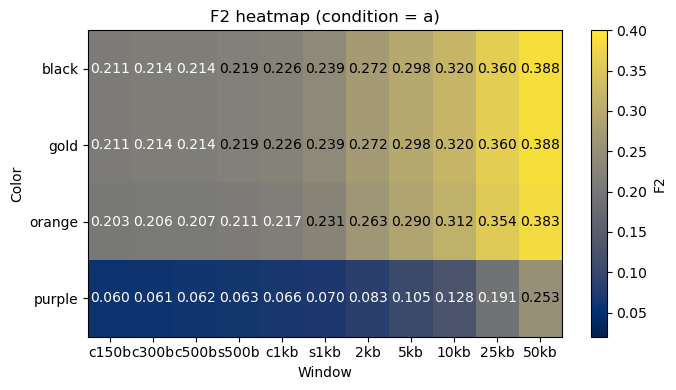

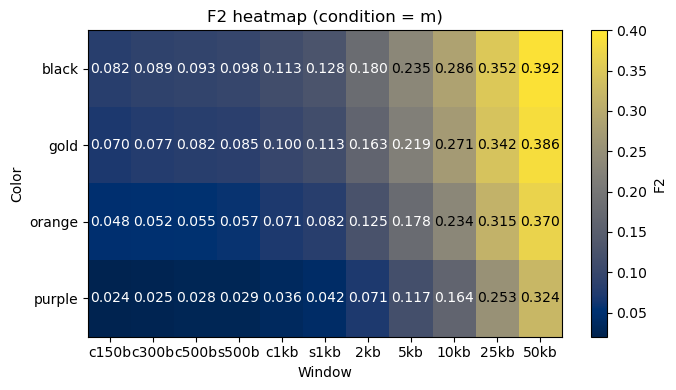

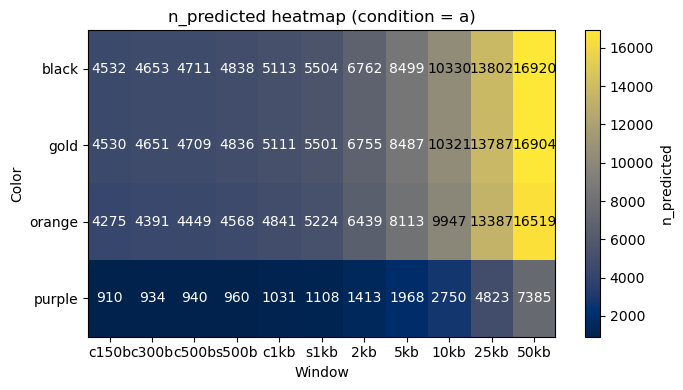

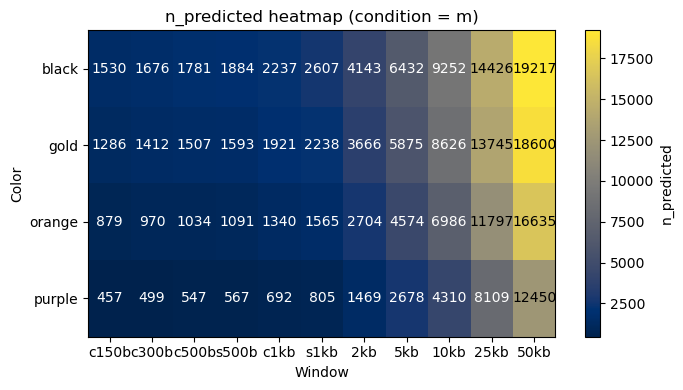

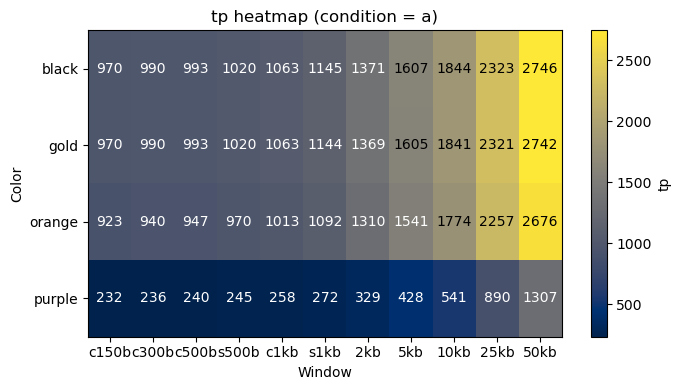

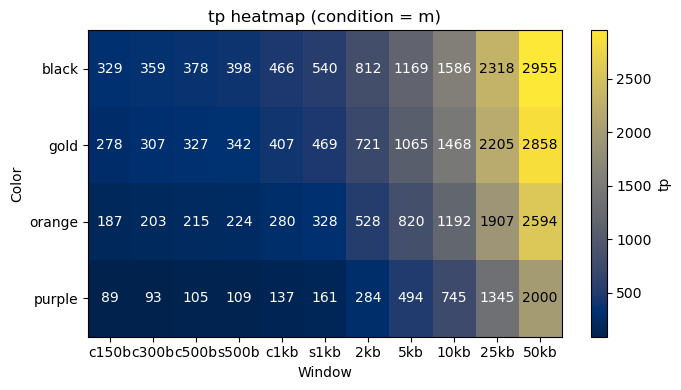

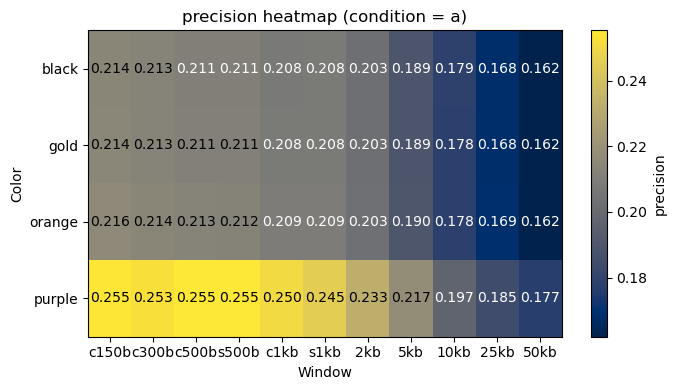

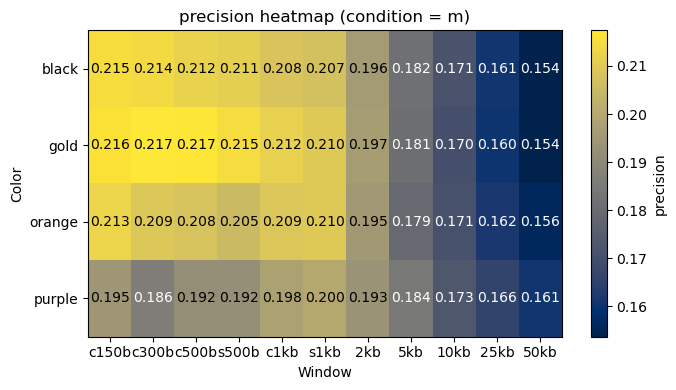

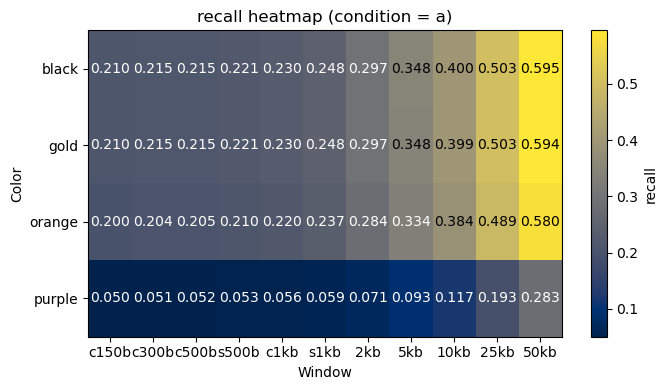

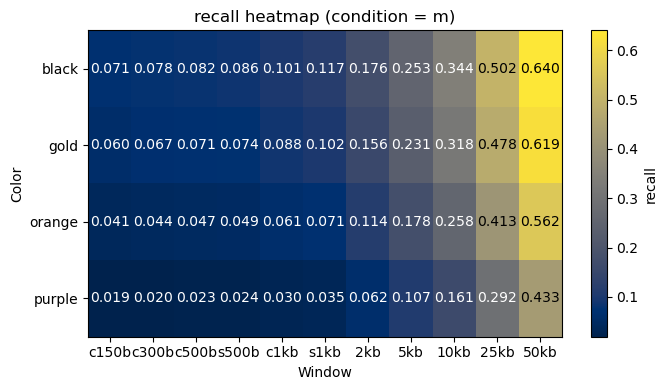

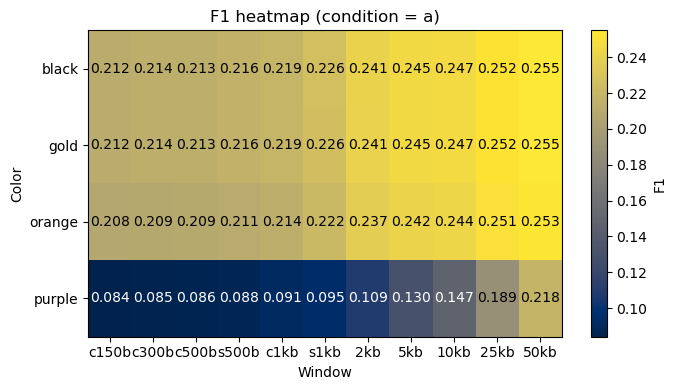

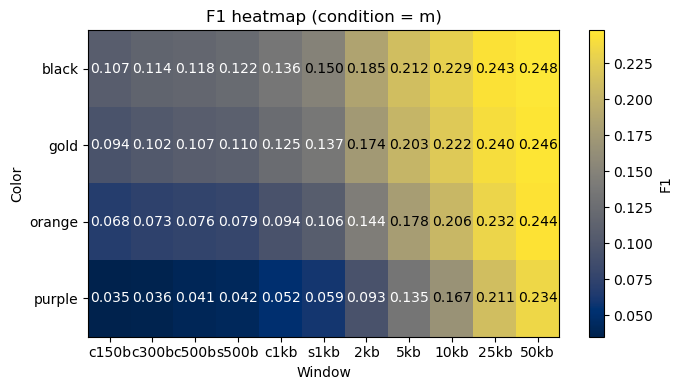

In [6]:
def plot_metric_heatmap(results_df, condition_value, metric, fmt=None):
    sub = results_df[results_df["condition"] == condition_value].copy()

    pivot = sub.pivot_table(
        index="color",
        columns="window",
        values=metric,
        aggfunc="mean"
    )

    # Ensure consistent column order
    pivot = pivot.reindex(columns=[w for w in window_order if w in pivot.columns])

    fig = matplotlib.pyplot.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)


    if metric == 'F2':
        im = ax.imshow(pivot.values, aspect="auto", cmap="cividis", vmin=0.02, vmax=0.4)
    else:
        im = ax.imshow(pivot.values, aspect="auto", cmap="cividis")

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels(list(pivot.columns), rotation=0)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(list(pivot.index))

    ax.set_title(f"{metric} heatmap (condition = {condition_value})")
    ax.set_xlabel("Window")
    ax.set_ylabel("Color")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(metric)

    # Choose annotation format
    if fmt is None:
        if metric in ["tp", "fp", "fn", "n_known", "n_predicted", "n_genes", "intersect"]:
            fmt = "{:d}"
        else:
            fmt = "{:.3f}"

    # Annotate values with adaptive text color
    norm = im.norm
    cmap = im.cmap
    
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if pandas.notna(v):
                rgba = cmap(norm(v))
                # perceived luminance (ITU-R BT.709)
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                text_color = "black" if luminance > 0.5 else "white"
    
                if fmt == "{:d}":
                    label = fmt.format(int(round(v)))
                else:
                    label = fmt.format(float(v))
    
                ax.text(j, i, label, ha="center", va="center", color=text_color)

    fig.tight_layout()
    return fig, ax


metrics_to_plot = ["F2", "n_predicted", "tp", "precision", "recall", 'F1']

for metric in metrics_to_plot:
    plot_metric_heatmap(results_df, "a", metric)
    plot_metric_heatmap(results_df, "m", metric)

matplotlib.pyplot.show()
